In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
# Dataset sederhana dari soal
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

In [12]:
# Inisialisasi dan latih model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [10]:
# Prediksi untuk evaluasi
y_pred = model.predict(X)

In [14]:
# --- TAMBAHAN METRIK EVALUASI ---
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)
mape = np.mean(np.abs((y - y_pred) / y)) * 100

In [16]:
print(f"R-Square: {r2:.4f}")
print(f"RMSE    : {rmse:.4f}")
print(f"MAE     : {mae:.4f}")
print(f"MSE     : {mse:.4f}")
print(f"MAPE    : {mape:.4f}%")

R-Square: 0.7470
RMSE    : 0.9962
MAE     : 0.8493
MSE     : 0.9924
MAPE    : 13.4291%


Accuracy : 0.9444
Precision: 0.9583
Recall   : 0.9345
F1 Score : 0.9432


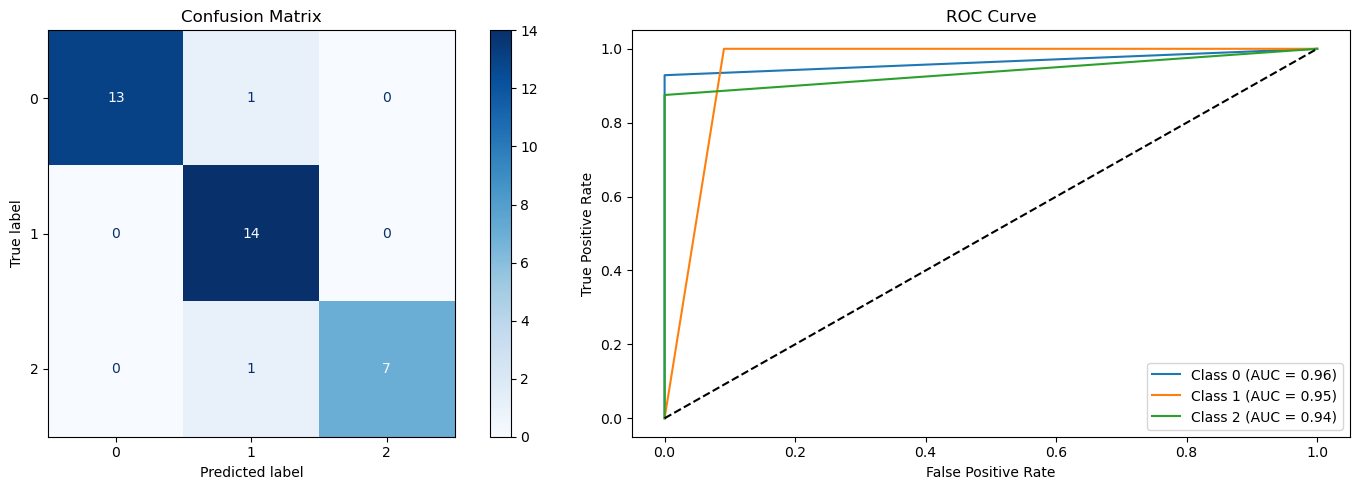

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# Muat dataset dan bagi data
wine = load_wine()
X = wine.data
y = wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Latih model
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

# Prediksi
y_pred = clf.predict(X_test)

# --- TAMBAHAN METRIK EVALUASI ---
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred, average='macro'):.4f}")

# Plot Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, ax=ax[0], cmap='Blues')
ax[0].set_title("Confusion Matrix")

# Plot ROC Curve (Multiclass)
# Binarize output untuk ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = clf.predict_proba(X_test)

for i in range(wine.target_names.size):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve')
ax[1].legend()

plt.tight_layout()
plt.show()